# Figures of the paper - *Exact topology of conservative multiplicative cascades: an ultrametric transfer-operator genus*

It uses the [`multifrac`](https://github.com/csabiu/multiplicative_cascade) cascade package for the **field generation** and the **multifractal spectrum**, and implements the paper's **transfer-operator genus**
directly below, so you can read the method, run it, and reuse it on your own cascades.

**How to run.** Clone or install the package from
[https://github.com/csabiu/multiplicative_cascade](https://github.com/csabiu/multiplicative_cascade), then execute this notebook top to bottom. Dependencies: `numpy`,
`scipy`, `matplotlib`, and `multifrac`. Each section regenerates one figure and writes
it to `figs/`.

| Figure | Section | Made with |
|---|---|---|
| 1: three cascades + their multifractal spectra | §II | `multifrac` |
| 2: building the cascade (exact mass propagation) | §II | explicit construction (the rule `multifrac` applies) |
| 3: construction & closure schematic | §III | TikZ diagram in the manuscript (not generated here) |
| 4: validation of the exact digital genus | §III–IV | inline transfer operator + `multifrac` |
| 5: the genus across the width dial | §V | inline transfer operator + `multifrac` |


In [65]:
import os
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({          # slightly larger labels/ticks for the paper figures
    "font.size": 13, "axes.labelsize": 15, "axes.titlesize": 14,
    "xtick.labelsize": 13, "ytick.labelsize": 13, "legend.fontsize": 12.5,
})
from scipy.ndimage import gaussian_filter

# the cascade package -- https://github.com/csabiu/multiplicative_cascade
try:
    from multifrac import multifrac, cascade_spectrum, generalized_dimensions
except ImportError:
    # not installed: this notebook ships inside the repo, so add its root
    import sys; sys.path.insert(0, os.path.abspath(".."))
    from multifrac import multifrac, cascade_spectrum, generalized_dimensions

os.makedirs("figs", exist_ok=True)
np.random.seed(0)
print("multifrac loaded; figures will be written to ./figs/")

multifrac loaded; figures will be written to ./figs/


## Figure 1: three cascades and their multifractal spectra

Three weight multisets of increasing singularity width, sharing one random-permutation
skeleton: a **Sierpinski monofractal** $[\tfrac13,\tfrac13,\tfrac13,0]$ (a fractal *set*:
$\Delta\alpha=0$, its spectrum is a single point), a **narrow** multifractal, and a
**wide** one. *Top (a–c):* the $\log_{10}\rho$ fields. *Bottom (d–f):* the exact spectrum
$\tau(q),D_q,f(\alpha)$ from `multifrac.cascade_spectrum` (lines) with the Chhabra–Jensen
measurement from `multifrac.generalized_dimensions` (points). The monofractal's $\tau$ is
straight, its $D_q$ flat and its $f(\alpha)$ a point; the multifractal parabolas widen with
$\Delta\alpha$.

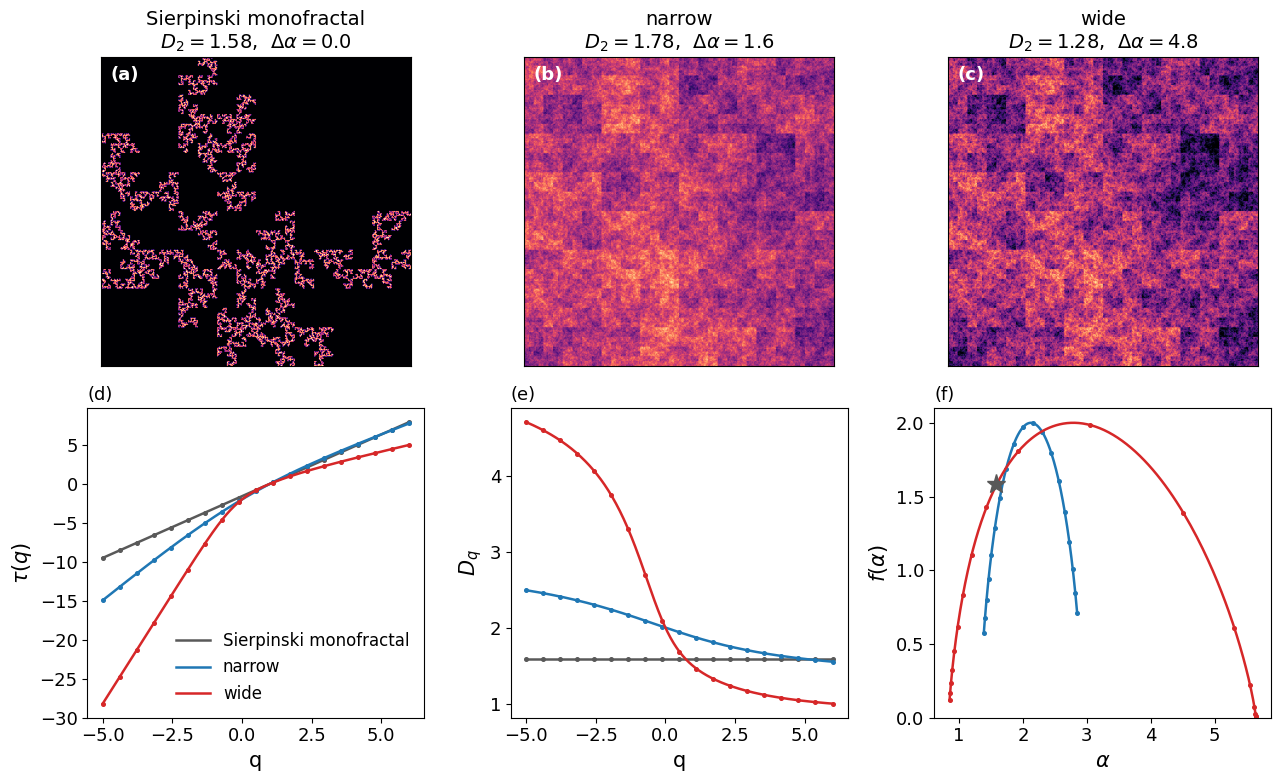

In [66]:
CAS = [("Sierpinski monofractal", [1/3, 1/3, 1/3, 0.0], "0.35"),
       ("narrow",                  [0.40, 0.28, 0.19, 0.13], "C0"),
       ("wide",                    [0.56, 0.28, 0.14, 0.02], "C3")]
qf = np.linspace(-5, 6, 400); qm = np.linspace(-5, 6, 19); NR = 20; SEED = 7

fig, ax = plt.subplots(2, 3, figsize=(13.0, 8.0))
for j, (name, w, col) in enumerate(CAS):
    sp = cascade_spectrum(w, base=2)                                  # excludes zero weights
    rho, _ = multifrac(w, dim=2, size=2, levels=8, seed=SEED)         # 512^2, shared skeleton
    rho = rho / rho.mean()
    ax[0, j].imshow(np.log10(np.maximum(rho, 1e-6)), origin="lower", cmap="magma")
    ax[0, j].set_xticks([]); ax[0, j].set_yticks([])
    ax[0, j].set_title(rf"{name}" "\n" rf"$D_2={sp['D2']:.2f}$,  $\Delta\alpha={sp['delta_alpha']:.1f}$", fontsize=14)

    th = cascade_spectrum(w, base=2, q=qf)                            # exact theory
    S  = [generalized_dimensions(multifrac(w, dim=2, size=2, levels=7, seed=100+r)[0], q=qm, base=2)
          for r in range(NR)]                                         # Chhabra-Jensen, averaged
    tm = np.mean([s["tau"] for s in S], 0); Dm = np.mean([s["D"] for s in S], 0)
    am = np.mean([s["alpha"] for s in S], 0); fm = np.mean([s["f"] for s in S], 0)
    ax[1, 0].plot(qf, th["tau"], "-", color=col, lw=1.8, label=name); ax[1, 0].plot(qm, tm, "o", color=col, ms=2.6)
    ax[1, 1].plot(qf, th["D"],   "-", color=col, lw=1.8);             ax[1, 1].plot(qm, Dm, "o", color=col, ms=2.6)
    if min(w) == 0:                                                   # monofractal -> point spectrum
        ax[1, 2].plot(th["alpha"][len(qf)//2], th["f"][len(qf)//2], "*", color=col, ms=14, zorder=5)
        ax[1, 2].plot(am, fm, "o", color=col, ms=2.6)
    else:
        g = th["f"] > -0.3
        ax[1, 2].plot(th["alpha"][g], th["f"][g], "-", color=col, lw=1.8); ax[1, 2].plot(am, fm, "o", color=col, ms=2.6)

for a, lab, xl, yl in [(ax[1,0],"(d)","q",r"$\tau(q)$"), (ax[1,1],"(e)","q",r"$D_q$"), (ax[1,2],"(f)",r"$\alpha$",r"$f(\alpha)$")]:
    a.set_xlabel(xl); a.set_ylabel(yl); a.set_title(lab, loc="left", fontsize=13)
for a, lab in zip(ax[0], ["(a)","(b)","(c)"]):
    a.text(0.03, 0.97, lab, transform=a.transAxes, color="w", va="top", fontsize=13, fontweight="bold")
ax[1, 0].legend(fontsize=12, frameon=False); ax[1, 2].set_ylim(0, 2.1)
fig.tight_layout()
fig.savefig("figs/cascade_fields_spectrum.pdf"); fig.savefig("figs/cascade_fields_spectrum.png", dpi=150)
plt.show()

## Figure 2: building the cascade with exact mass propagation

The construction rule made explicit (the same rule `multifrac` applies). A cell is split
into $n=b^d$ children that receive a random *permutation* of a fixed weight multiset
$\{p_i\}$; recursing with an *independent* permutation inside each child builds the
cascade. Every cell is shaded by its **exact** propagated density
$\rho=\prod_k (n\,w_k)$, the quantity the transfer operator acts on, so the multiplicative
dimming is faithful: heavy regions brighten and voids darken as the depth grows. Weights
$\{0.40,0.28,0.19,0.13\}$, the narrow multifractal of Fig. 1.

level-2 density range rho: 0.270 .. 2.560


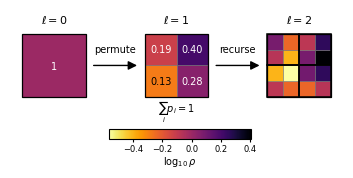

In [61]:
from matplotlib.patches import Rectangle
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

CMAP = plt.get_cmap("inferno_r")
n = 4                                    # n = b^d = 2^2
w = np.array([0.40, 0.28, 0.19, 0.13])   # narrow multifractal multiset (as in Fig. 1)

# level 1: one permutation of the multiset (row 0 = bottom)
W1 = np.array([[0.13, 0.28],
               [0.19, 0.40]])
dens1 = n * W1

# level 2: an INDEPENDENT permutation inside each level-1 parent
child = {
    (0, 0): np.array([[0.40, 0.28], [0.19, 0.13]]),
    (0, 1): np.array([[0.13, 0.19], [0.28, 0.40]]),
    (1, 0): np.array([[0.28, 0.13], [0.40, 0.19]]),
    (1, 1): np.array([[0.19, 0.40], [0.13, 0.28]]),
}
dens2 = np.zeros((4, 4))
for (pr, pc), cw in child.items():
    dens2[pr*2:pr*2+2, pc*2:pc*2+2] = (n * W1[pr, pc]) * (n * cw)

dens0 = np.array([[1.0]])
allv = np.log10(np.concatenate([dens0.ravel(), dens1.ravel(), dens2.ravel()]))
norm = Normalize(allv.min(), allv.max())


def _grid(ax, x0, yb, cs, dens, annot=None, parent=False):
    ns = dens.shape[0]
    for r in range(ns):
        for c in range(ns):
            fc = CMAP(norm(np.log10(dens[r, c])))
            ax.add_patch(Rectangle((x0+c*cs, yb+r*cs), cs, cs,
                                   facecolor=fc, edgecolor="0.45", lw=0.4))
            if annot is not None and annot[r][c]:
                lum = 0.299*fc[0] + 0.587*fc[1] + 0.114*fc[2]
                ax.text(x0+(c+0.5)*cs, yb+(r+0.5)*cs, annot[r][c], ha="center",
                        va="center", fontsize=7.0, color="k" if lum > 0.55 else "w")
    if parent:
        for pr in (0, 1):
            for pc in (0, 1):
                ax.add_patch(Rectangle((x0+pc*2*cs, yb+pr*2*cs), 2*cs, 2*cs,
                                       fill=False, edgecolor="k", lw=1.1))
    ax.add_patch(Rectangle((x0, yb), ns*cs, ns*cs, fill=False, edgecolor="k", lw=0.9))


fig = plt.figure(figsize=(3.4, 2.0))
ax = fig.add_axes([0.01, 0.27, 0.98, 0.70])
ax.set_aspect("equal"); ax.axis("off")
ax.set_xlim(-0.25, 6.55); ax.set_ylim(-0.5, 1.8)

# all three stages fill the SAME box (fixed domain, conserved area); the cells
# get smaller as the level grows, not the box.
BS = 1.3                                  # box size, identical at every level
_grid(ax, 0.0, 0.0, BS, dens0, annot=[["$1$"]])
ax.text(0.65, 1.52, r"$\ell=0$", ha="center", fontsize=8)
ax.annotate("", xy=(2.4, 0.65), xytext=(1.4, 0.65),
            arrowprops=dict(arrowstyle="-|>", lw=1.0, color="k"))
ax.text(1.9, 0.92, "permute", ha="center", fontsize=7)
_grid(ax, 2.5, 0.0, BS/2, dens1, annot=[["0.13", "0.28"], ["0.19", "0.40"]])
ax.text(3.15, 1.52, r"$\ell=1$", ha="center", fontsize=8)
ax.text(3.15, -0.30, r"$\sum_i p_i=1$", ha="center", fontsize=7)
ax.annotate("", xy=(4.9, 0.65), xytext=(3.9, 0.65),
            arrowprops=dict(arrowstyle="-|>", lw=1.0, color="k"))
ax.text(4.4, 0.92, "recurse", ha="center", fontsize=7)
_grid(ax, 5.0, 0.0, BS/4, dens2, parent=True)
ax.text(5.65, 1.52, r"$\ell=2$", ha="center", fontsize=8)

cax = fig.add_axes([0.30, 0.25, 0.42, 0.05])
cb = fig.colorbar(ScalarMappable(norm=norm, cmap=CMAP), cax=cax, orientation="horizontal")
cb.set_label(r"$\log_{10}\rho$", fontsize=7, labelpad=1)
cb.ax.tick_params(labelsize=6, length=2, pad=1)

fig.savefig("figs/cascade_construction.pdf", bbox_inches="tight", pad_inches=0.02)
print("level-2 density range rho: %.3f .. %.3f" % (dens2.min(), dens2.max()))
plt.show()

## The exact digital genus: a transfer operator on the tree

The paper's central result. For the level-$j$ excursion set the 2D cubical Euler density
is additive over $2\times2$ windows,
$$\chi_j/A = p_1 - p_{Eh} - p_{Ev} + p_F,$$
with $p_1$ the area fraction, $p_{Eh},p_{Ev}$ the adjacent-pair probabilities and
$p_F$ the $2\times2$-block probability. Each closes in **closed form** via a transfer
operator on the $b$-ary tree: a cell's log-density law is $\mathcal{T}^{\,j}\delta_0$
with $(\mathcal{T}P)(x)=\tfrac1n\sum_i P(x-\ln(b^d p_i))$; two neighbours share an
ancestral prefix, split conservatively (siblings drawn **without replacement**), then
evolve independently. The functions below evaluate this for the base-2, 2D cascade
($n=b^d=4$). 

In [62]:
from math import factorial

B, D = 2, 2 # base, dimension  -> n = b^d = 4 children
N = B ** D

def _atoms(C, m):
    """Exact (position, prob) atoms of the m-level log-density (multinomial, n=4)."""
    pos, pr, fm = [], [], factorial(m)
    for a in range(m + 1):
        for b in range(m - a + 1):
            for c in range(m - a - b + 1):
                d = m - a - b - c
                pos.append(a*C[0] + b*C[1] + c*C[2] + d*C[3])
                pr.append(fm/(factorial(a)*factorial(b)*factorial(c)*factorial(d))/N**m)
    return np.array(pos), np.array(pr)

def genus_theory(weights, J, thresholds, dx=0.005):
    """Exact digital Euler density chi_J/A by the transfer operator. Returns a dict
    of p1, pE (=pEh=pEv), pF and chi at each log-density threshold."""
    w = np.asarray(weights, float); w = w / w.sum()
    C = np.log(N * w)                                       # increments ln(b^d p_i)
    x = np.arange(J*C.min() - 5.0, J*C.max() + 5.0, dx)     # log-density grid
    ac = {m: _atoms(C, m) for m in range(J + 1)}
    def shift(arr, s): return np.interp(x + s, x, arr, left=arr[0], right=arr[-1])
    def Psi1(p): return sum(shift(p, ci) for ci in C) / N                      # one child
    def Psi2(p):                                                               # sibling pair
        s = [shift(p, ci) for ci in C]                                         #  (no replace)
        return (sum(s)**2 - sum(si*si for si in s)) / (N*(N-1))
    def Phi4(p):
        o = np.ones_like(p)
        for ci in C: o = o * shift(p, ci)
        return o
    def Smooth(m, psi):
        if m == 0: return psi
        pos, pr = ac[m]; o = np.zeros_like(psi)
        for p, wt in zip(pos, pr): o += wt * shift(psi, p)
        return o
    def inner(k, g):
        pos, pr = ac[k]; return float(np.sum(pr * np.interp(pos, x, g)))
    def Gfunc(j, psi):                                                          # adjacent pair
        dn = 2**j - 1
        return sum((2**k / dn) * inner(k, Psi2(Smooth(j-1-k, psi))) for k in range(j))
    def Ffunc(j, phi):                                                          # 2x2 plaquette
        if j == 1: return float(np.prod([np.interp(ci, x, phi) for ci in C]))
        L = 2**j; pe = (L//2)/(L-1); po = (L//2 - 1)/(L-1)                      # exact alignment
        return pe*pe*inner(j-1, Phi4(phi)) + 2*pe*po*Gfunc(j-1, Psi2(phi)) + po*po*Ffunc(j-1, Psi1(phi))
    posJ, prJ = ac[J]
    p1, pE, pF = [], [], []
    for t in thresholds:
        ind = (x > t).astype(float)
        p1.append(float(np.sum(prJ[posJ > t])))            # exact area fraction (atoms)
        pE.append(Gfunc(J, ind)); pF.append(Ffunc(J, ind))
    p1, pE, pF = map(np.array, (p1, pE, pF))
    return dict(p1=p1, pE=pE, pF=pF, chi=p1 - 2*pE + pF)

def safe_thresholds(weights, J, lo, hi, n_thr, dx=0.005):
    """Thresholds in the GAPS between the density atoms: the bare-measure genus is a
    step function, so sampling between atoms traces its envelope cleanly."""
    w = np.asarray(weights, float); w = w / w.sum(); C = np.log(N * w)
    u = np.unique(np.round(np.sort(_atoms(C, J)[0]), 9))
    g = np.diff(u); mids = 0.5 * (u[:-1] + u[1:])
    cand = np.unique(mids[(g > 6*dx) & (mids >= lo) & (mids <= hi)])
    if len(cand) > n_thr: cand = cand[np.linspace(0, len(cand)-1, n_thr).round().astype(int)]
    return cand

def genus_measured(weights, J, thresholds, nreal=80, seed0=1):
    """Measure the digital genus over `nreal` multifrac realisations (mean +- s.e.)."""
    nt = len(thresholds)
    P1, PE, PF, CHI = (np.empty((nreal, nt)) for _ in range(4))
    for r in range(nreal):
        np.random.seed(seed0 + r)
        field, _ = multifrac(weights, dim=2, size=2, levels=J-1, verbose=False)
        lr = np.log(field / field.mean())
        for i, t in enumerate(thresholds):
            on = lr > t
            pEh = (on[:, :-1] & on[:, 1:]).mean(); pEv = (on[:-1, :] & on[1:, :]).mean()
            pF  = (on[:-1, :-1] & on[:-1, 1:] & on[1:, :-1] & on[1:, 1:]).mean()
            P1[r, i] = on.mean(); PE[r, i] = 0.5*(pEh+pEv); PF[r, i] = pF
            CHI[r, i] = on.mean() - pEh - pEv + pF
    sem = lambda A: (A.mean(0), A.std(0, ddof=1)/np.sqrt(nreal) if nreal > 1 else np.zeros(nt))
    out = {}
    for k, A in zip(("p1","pE","pF","chi"), (P1,PE,PF,CHI)):
        out[k], out[k+"e"] = sem(A)
    return out

print("genus method ready: genus_theory / safe_thresholds / genus_measured")

genus method ready: genus_theory / safe_thresholds / genus_measured


## Figure 4: Validating the exact digital genus

Transfer-operator prediction (lines) vs direct `multifrac` realisations (points), for
$b=2$ weights $[0.42,0.30,0.20,0.08]$ at $j=8$. The joint exceedance probabilities and
the assembled genus curve agree to one part in $10^3$ ($p_1$ exactly). *(This cell runs
the measurement over many realisations, a few tens of seconds.)*

chi: max|theory-measured| = 0.0001  (mean 0.0000)


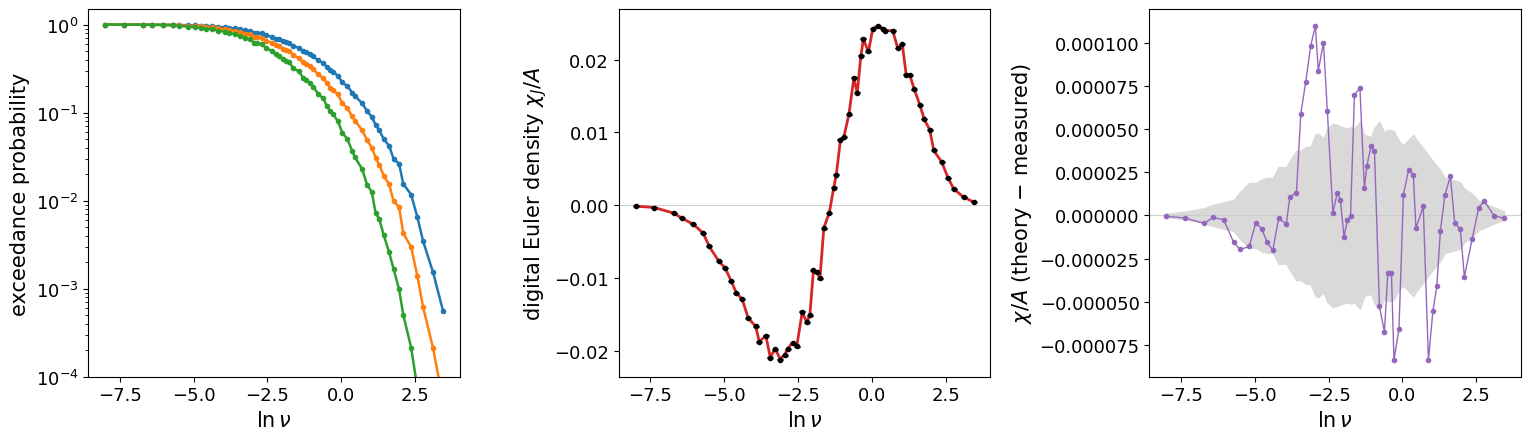

In [63]:
J = 8
wg = [0.42, 0.30, 0.20, 0.08]
C  = np.log(N * np.asarray(wg) / np.sum(wg))
thr = safe_thresholds(wg, J, J*C.min() + 0.6, J*C.max() - 0.6, 60)
A = genus_theory(wg, J, thr)
M = genus_measured(wg, J, thr, nreal=120)
print(f"chi: max|theory-measured| = {np.abs(A['chi']-M['chi']).max():.4f}  (mean {np.abs(A['chi']-M['chi']).mean():.4f})")

fig, ax = plt.subplots(1, 3, figsize=(15.5, 4.6))
a = ax[0]
for key, col, lab in [("p1","C0",r"$p_1$ (area)"), ("pE","C1",r"$p_E$ (pair)"), ("pF","C2",r"$p_F$ (2$\times$2)")]:
    a.plot(thr, A[key], "-", color=col, lw=1.8, label=lab+" theory")
    a.errorbar(thr, M[key], yerr=M[key+"e"], fmt="o", ms=3, color=col, capsize=1.5, elinewidth=0.8, label=lab+" measured")
a.set_yscale("log"); a.set_ylim(1e-4, 1.5); a.set_xlabel(r"$\ln\nu$"); a.set_ylabel("exceedance probability")

a = ax[1]; a.axhline(0, color="0.8", lw=0.7)
a.plot(thr, A["chi"], "-", color="C3", lw=2.0, label="transfer-operator (exact)")
a.errorbar(thr, M["chi"], yerr=M["chie"], fmt="o", color="k", ms=3, capsize=2, elinewidth=0.9, label="cascade realisations")
a.set_xlabel(r"$\ln\nu$"); a.set_ylabel(r"digital Euler density $\chi_J/A$")

a = ax[2]; a.axhline(0, color="0.8", lw=0.7)
a.fill_between(thr, -M["chie"], M["chie"], color="0.85", label=r"$\pm$ sampling s.e.")
a.plot(thr, A["chi"]-M["chi"], "o-", color="C4", ms=3, lw=1.0, label="residual")
a.set_xlabel(r"$\ln\nu$"); a.set_ylabel(r"$\chi/A$ (theory $-$ measured)")

fig.tight_layout()
fig.savefig("figs/cascade_digital_topology.pdf")
fig.savefig("figs/cascade_digital_topology.png", dpi=150)
plt.show()

## Figure 5: The genus across the multifractal-width dial

A geometric weight family $p_i\propto\rho^{\,i}$ swept from near-monofractal to strongly
intermittent. Because its log-increments are equally spaced, turning the width dial just
**rescales** the threshold axis: the genus is *exactly self-similar* (left, centred on the
log-density mean, same shape, stretching width; right, standardised by
$\hat\nu=(\ln\rho-\mu)/\sigma$, universal collapse). *(Runs several widths × realisations,
up to ~a minute.)*

rho=0.85  Delta_alpha=0.70  D2=1.95  chi max|d|=0.0001
rho=0.62  Delta_alpha=2.07  D2=1.66  chi max|d|=0.0001
rho=0.45  Delta_alpha=3.46  D2=1.28  chi max|d|=0.0001
rho=0.32  Delta_alpha=4.93  D2=0.93  chi max|d|=0.0001


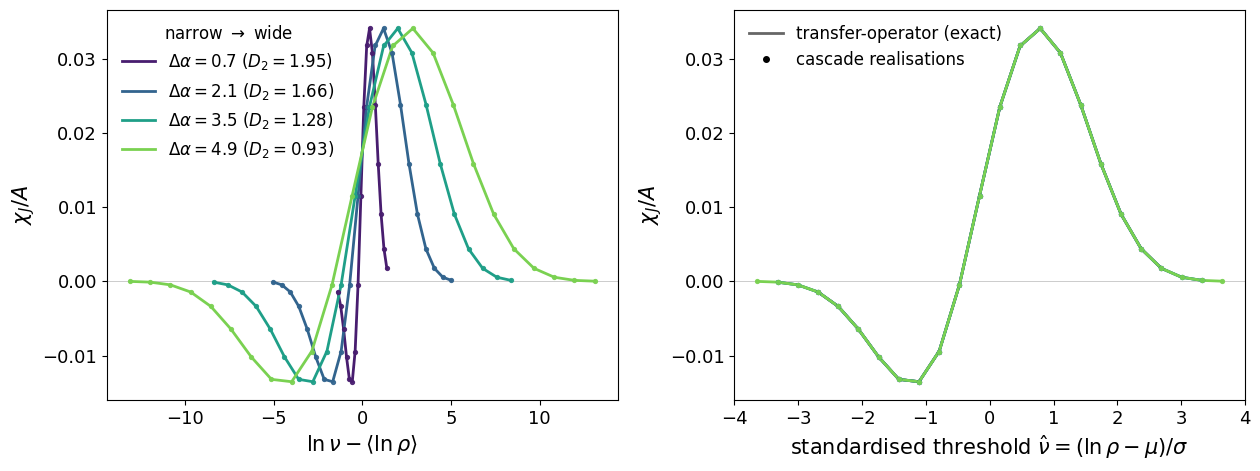

In [64]:
def geom_weights(rho, n=4):
    p = rho ** np.arange(n); return p / p.sum()

J = 8
RHOS = [0.85, 0.62, 0.45, 0.32]
colors = plt.cm.viridis(np.linspace(0.08, 0.80, len(RHOS)))
runs = []
for rho in RHOS:
    w = geom_weights(rho)
    C = np.log(N * w)
    da = np.log2(w.max()/w.min()); D2 = -np.log2((w**2).sum())
    mu = J*C.mean(); sig = np.sqrt(J*C.var())
    thr = safe_thresholds(w, J, J*C.min()+0.5, J*C.max()-0.5, 55)
    A = genus_theory(w, J, thr); Mm = genus_measured(w, J, thr, nreal=60)
    runs.append(dict(da=da, D2=D2, mu=mu, sig=sig, thr=thr, A=A, M=Mm))
    print(f"rho={rho:.2f}  Delta_alpha={da:.2f}  D2={D2:.2f}  chi max|d|={np.abs(A['chi']-Mm['chi']).max():.4f}")

fig, ax = plt.subplots(1, 2, figsize=(12.8, 4.9))
a = ax[0]; a.axhline(0, color="0.8", lw=0.7)
for run, col in zip(runs, colors):
    xc = run["thr"] - run["mu"]
    a.plot(xc, run["A"]["chi"], "-", color=col, lw=2.0, label=fr"$\Delta\alpha={run['da']:.1f}$ ($D_2={run['D2']:.2f}$)")
    a.errorbar(xc, run["M"]["chi"], yerr=run["M"]["chie"], fmt="o", color=col, ms=2.8, capsize=0, elinewidth=0.7, alpha=0.9)
a.set_xlabel(r"$\ln\nu - \langle\ln\rho\rangle$"); a.set_ylabel(r"$\chi_J/A$")
#a.set_title(r"(a) genus across the width dial (centred)", loc="left", fontsize=10)
a.legend(fontsize=12, frameon=False, title="narrow $\\to$ wide", title_fontsize=12, loc="upper left")
b = ax[1]; b.axhline(0, color="0.8", lw=0.7)
for run, col in zip(runs, colors):
    xs = (run["thr"] - run["mu"]) / run["sig"]
    b.plot(xs, run["A"]["chi"], "-", color=col, lw=2.0)
    b.errorbar(xs, run["M"]["chi"], yerr=run["M"]["chie"], fmt="o", color=col, ms=2.8, capsize=0, elinewidth=0.7, alpha=0.9)
b.set_xlabel(r"standardised threshold $\hat\nu=(\ln\rho-\mu)/\sigma$"); b.set_ylabel(r"$\chi_J/A$")
#b.set_title(r"(b) the same curves collapse under $\hat\nu$", loc="left", fontsize=10)
b.plot([], [], "-", color="0.4", lw=2.0, label="transfer-operator (exact)")
b.plot([], [], "o", color="k", ms=4, label="cascade realisations")
b.legend(fontsize=12, frameon=False, loc="upper left")
fig.tight_layout()
fig.savefig("figs/cascade_width_topology.pdf"); fig.savefig("figs/cascade_width_topology.png", dpi=150)
plt.show()